In [93]:
import sys

print(sys.executable)
print(sys.version)

/Users/senuka/Documents/Projects/My Projects/quantitative-research-stock-trend/.venv/bin/python
3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import torch
import yfinance as yf
import ta
import backtesting

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("yfinance:", yf.__version__)
print("Environment OK")

NumPy: 2.5.2
Pandas: 3.0.5
Scikit-learn: 1.9.0
PyTorch: 2.13.0
yfinance: 1.6.0
Environment OK


# AAPL Short-Term Stock Trend Prediction

## 1. Objective

This notebook prepares and validates the historical dataset used
for short-term stock trend prediction.

The assessment requires one year of daily OHLCV data for a single
instrument. AAPL (Apple Inc.) is selected as the modeling and
backtesting instrument.

## 2. Data Source

Historical AAPL market data is collected using Yahoo Finance
through the `yfinance` Python package.

## 3. Dataset Requirements

- Instrument: AAPL
- Frequency: Daily
- Period: 1 year
- Required market data: OHLCV
- Modeling features: OHLC + five technical indicators

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [96]:
ticker = "AAPL"

data = yf.download(
    ticker,
    period="1y",
    interval="1d",
    auto_adjust=False,
    progress=False
)

data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2025-08-18,230.0402,230.8900,233.1200,230.1100,231.7000,37476200
2025-08-19,229.7115,230.5600,232.8700,229.3500,231.2800,39402600
2025-08-20,225.1782,226.0100,230.4700,225.7700,229.9800,42263900
2025-08-21,224.0723,224.9000,226.5200,223.7800,226.2700,30621200
2025-08-22,226.9218,227.7600,229.0900,225.4100,226.1700,42477800


In [97]:
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nDate range:")
print(data.index.min(), "→", data.index.max())

print("\nLast 5 rows:")
display(data.tail())

Shape: (251, 6)

Columns:
MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Date range:
2025-08-18 00:00:00 → 2026-08-17 00:00:00

Last 5 rows:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2026-08-11,304.9100,304.9100,309.9700,302.7900,307.7500,37476700
2026-08-12,302.2500,302.2500,305.6600,300.5700,305.1000,41657800
2026-08-13,305.2600,305.2600,306.0000,302.0500,304.2100,40349300
2026-08-14,305.9300,305.9300,307.4900,304.3000,306.0000,28186700
2026-08-17,304.6400,304.6400,307.6600,302.9390,306.2100,18983866


In [98]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [99]:
data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-08-18,230.0402,230.8900,233.1200,230.1100,231.7000,37476200
2025-08-19,229.7115,230.5600,232.8700,229.3500,231.2800,39402600
2025-08-20,225.1782,226.0100,230.4700,225.7700,229.9800,42263900
2025-08-21,224.0723,224.9000,226.5200,223.7800,226.2700,30621200
2025-08-22,226.9218,227.7600,229.0900,225.4100,226.1700,42477800


In [100]:
ohlcv = data[["Open", "High", "Low", "Close", "Volume"]].copy()

ohlcv.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2025-08-18,231.7000,233.1200,230.1100,230.8900,37476200
2025-08-19,231.2800,232.8700,229.3500,230.5600,39402600
2025-08-20,229.9800,230.4700,225.7700,226.0100,42263900
2025-08-21,226.2700,226.5200,223.7800,224.9000,30621200
2025-08-22,226.1700,229.0900,225.4100,227.7600,42477800


In [101]:
print("Shape:", ohlcv.shape)
print("\nColumns:", list(ohlcv.columns))

Shape: (251, 5)

Columns: ['Open', 'High', 'Low', 'Close', 'Volume']


In [102]:
print("Index type:", type(ohlcv.index))
print("Timezone:", ohlcv.index.tz)
print("Sorted:", ohlcv.index.is_monotonic_increasing)
print("Duplicate dates:", ohlcv.index.duplicated().sum())

Index type: <class 'pandas.DatetimeIndex'>
Timezone: None
Sorted: True
Duplicate dates: 0


In [103]:
missing = ohlcv.isna().sum()

print("Missing values:")
display(missing)

Missing values:


Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [104]:
print("Total missing values:", ohlcv.isna().sum().sum())

Total missing values: 0


In [105]:
invalid_high = (
    (ohlcv["High"] < ohlcv["Open"]) |
    (ohlcv["High"] < ohlcv["Close"]) |
    (ohlcv["High"] < ohlcv["Low"])
)

invalid_low = (
    (ohlcv["Low"] > ohlcv["Open"]) |
    (ohlcv["Low"] > ohlcv["Close"])
)

print("Invalid high relationships:", invalid_high.sum())
print("Invalid low relationships:", invalid_low.sum())

Invalid high relationships: 0
Invalid low relationships: 0


In [106]:
print("Non-positive OHLC values:")

for column in ["Open", "High", "Low", "Close"]:
    count = (ohlcv[column] <= 0).sum()
    print(f"{column}: {count}")

Non-positive OHLC values:
Open: 0
High: 0
Low: 0
Close: 0


In [107]:
ohlcv.describe()

Price,Open,High,Low,Close,Volume
count,251.0000,251.0000,251.0000,251.0000,251.0000
mean,273.2178,276.1881,270.5806,273.4888,49616350.8606
std,25.1416,25.7237,24.9213,25.4415,22729800.4158
min,226.1700,226.5200,223.7800,224.9000,17910600.0000
25%,256.3350,258.7800,254.1650,256.4600,38655500.0000
50%,269.9900,273.0600,267.1100,270.1400,45018300.0000
75%,291.3600,294.7550,288.4900,291.3550,52688550.0000
max,340.0300,344.5700,337.3500,340.0800,261775500.0000


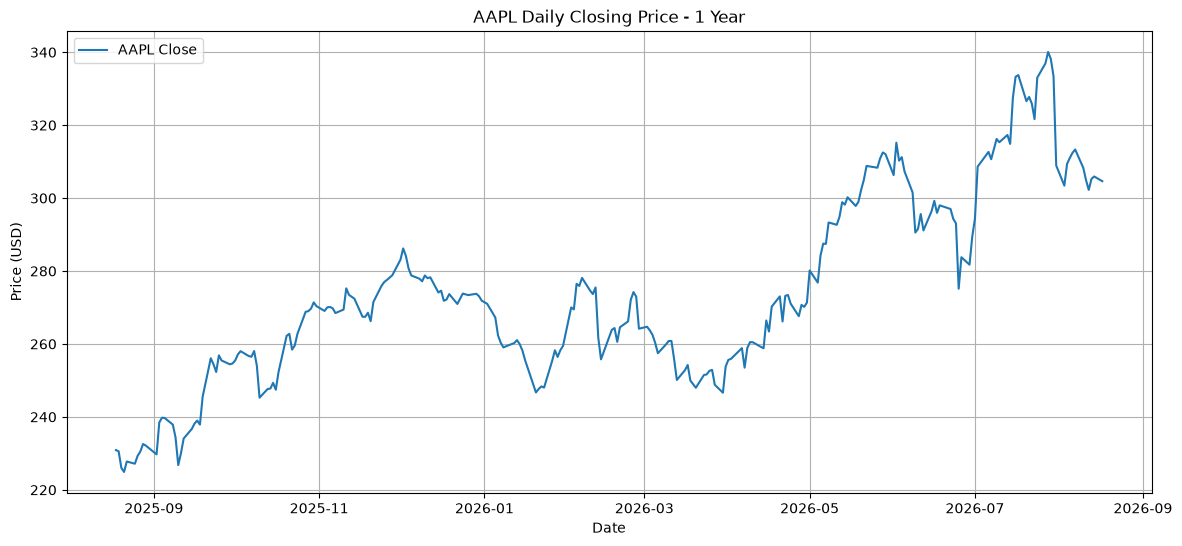

In [108]:
plt.figure(figsize=(14, 6))

plt.plot(
    ohlcv.index,
    ohlcv["Close"],
    label="AAPL Close"
)

plt.title("AAPL Daily Closing Price - 1 Year")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

In [109]:
daily_returns = ohlcv["Close"].pct_change()

print("Daily return statistics:")
display(daily_returns.describe())

Daily return statistics:


count   250.0000
mean      0.0012
std       0.0158
min      -0.0735
25%      -0.0067
50%       0.0011
75%       0.0089
max       0.0484
Name: Close, dtype: float64

In [110]:
print("Largest daily gain:", daily_returns.max())
print("Largest daily loss:", daily_returns.min())

Largest daily gain: 0.0484068203126522
Largest daily loss: -0.07353864245054431


In [111]:
daily_returns = ohlcv["Close"].pct_change()

print("Daily return statistics:")
display(daily_returns.describe())

Daily return statistics:


count   250.0000
mean      0.0012
std       0.0158
min      -0.0735
25%      -0.0067
50%       0.0011
75%       0.0089
max       0.0484
Name: Close, dtype: float64

In [112]:
print("Largest daily gain:", daily_returns.max())
print("Largest daily loss:", daily_returns.min())

Largest daily gain: 0.0484068203126522
Largest daily loss: -0.07353864245054431


In [113]:
raw_path = "../data/raw/AAPL_1y_daily.csv"

ohlcv.to_csv(raw_path)

print(f"Saved dataset to: {raw_path}")

Saved dataset to: ../data/raw/AAPL_1y_daily.csv


In [114]:
import os

print("File exists:", os.path.exists(raw_path))
print("File size:", os.path.getsize(raw_path), "bytes")

File exists: True
File size: 22623 bytes


In [115]:
print("=" * 50)
print("AAPL DATASET SUMMARY")
print("=" * 50)

print(f"Instrument: AAPL")
print(f"Frequency: Daily")
print(f"Rows: {len(ohlcv)}")
print(f"Columns: {len(ohlcv.columns)}")
print(f"Start: {ohlcv.index.min().date()}")
print(f"End: {ohlcv.index.max().date()}")
print(f"Missing values: {ohlcv.isna().sum().sum()}")
print(f"Duplicate dates: {ohlcv.index.duplicated().sum()}")
print(f"Sorted chronologically: {ohlcv.index.is_monotonic_increasing}")

AAPL DATASET SUMMARY
Instrument: AAPL
Frequency: Daily
Rows: 251
Columns: 5
Start: 2025-08-18
End: 2026-08-17
Missing values: 0
Duplicate dates: 0
Sorted chronologically: True


## 9. Technical Indicator Engineering

The research paper combines OHLC price information with technical
indicators to represent different aspects of historical market behavior.

For this assessment, five indicators from the paper are selected:

- MA5
- EMA20
- MACD
- ATR
- ROC

The indicators are calculated using historical information only.

In [116]:
# Reload the validated dataset

ohlcv = pd.read_csv(
    "../data/raw/AAPL_1y_daily.csv",
    index_col=0,
    parse_dates=True
)

ohlcv.head()

,Open,High,Low,Close,Volume
Date,,,,,
2025-08-18,231.7000,233.1200,230.1100,230.8900,37476200
2025-08-19,231.2800,232.8700,229.3500,230.5600,39402600
2025-08-20,229.9800,230.4700,225.7700,226.0100,42263900
2025-08-21,226.2700,226.5200,223.7800,224.9000,30621200
2025-08-22,226.1700,229.0900,225.4100,227.7600,42477800


In [117]:
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.volatility import AverageTrueRange
from ta.momentum import ROCIndicator

In [118]:
ohlcv["MA5"] = SMAIndicator(
    close=ohlcv["Close"],
    window=5
).sma_indicator()

In [119]:
ohlcv["MA5"] = SMAIndicator(
    close=ohlcv["Close"],
    window=5
).sma_indicator()

In [120]:
ohlcv["EMA20"] = EMAIndicator(
    close=ohlcv["Close"],
    window=20
).ema_indicator()

In [ ]:
macd_indicator = MACD(
    close=ohlcv["Close"]
)

ohlcv["MACD"] = macd_indicator.macd()

In [ ]:
atr_indicator = AverageTrueRange(
    high=ohlcv["High"],
    low=ohlcv["Low"],
    close=ohlcv["Close"],
    window=14
)

ohlcv["ATR"] = atr_indicator.average_true_range()

In [ ]:
roc_indicator = ROCIndicator(
    close=ohlcv["Close"],
    window=12
)

ohlcv["ROC"] = roc_indicator.roc()

In [128]:
from ta.trend import MACD
from ta.volatility import AverageTrueRange
from ta.momentum import ROCIndicator

In [129]:
# MACD
macd_indicator = MACD(close=ohlcv["Close"])
ohlcv["MACD"] = macd_indicator.macd()

# ATR
atr_indicator = AverageTrueRange(
    high=ohlcv["High"],
    low=ohlcv["Low"],
    close=ohlcv["Close"],
    window=14
)
ohlcv["ATR"] = atr_indicator.average_true_range()

# ROC
roc_indicator = ROCIndicator(
    close=ohlcv["Close"],
    window=12
)
ohlcv["ROC"] = roc_indicator.roc()

In [130]:
print(ohlcv.columns.tolist())

['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'EMA20', 'MACD', 'ATR', 'ROC']


In [131]:
indicator_columns = [
    "MA5",
    "EMA20",
    "MACD",
    "ATR",
    "ROC"
]

print("Missing values in indicators:")
display(ohlcv[indicator_columns].isna().sum())

Missing values in indicators:


MA5       4
EMA20    19
MACD     25
ATR       0
ROC      12
dtype: int64

In [132]:
first_valid_index = ohlcv[indicator_columns].dropna().index[0]

print("First row with all indicators available:")
print(first_valid_index)

print("\nRows before first valid feature row:")
print(ohlcv.index.get_loc(first_valid_index))

First row with all indicators available:
2025-09-23 00:00:00

Rows before first valid feature row:
25


In [133]:
features = ohlcv.dropna(
    subset=indicator_columns
).copy()

In [134]:
print("Original rows:", len(ohlcv))
print("Rows after indicator warm-up:", len(features))
print("Rows removed:", len(ohlcv) - len(features))

Original rows: 251
Rows after indicator warm-up: 226
Rows removed: 25


In [136]:
feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "MA5",
    "EMA20",
    "MACD",
    "ATR",
    "ROC"
]

In [137]:
print("Remaining missing values:")
display(features[feature_columns].isna().sum())

Remaining missing values:


Open     0
High     0
Low      0
Close    0
MA5      0
EMA20    0
MACD     0
ATR      0
ROC      0
dtype: int64

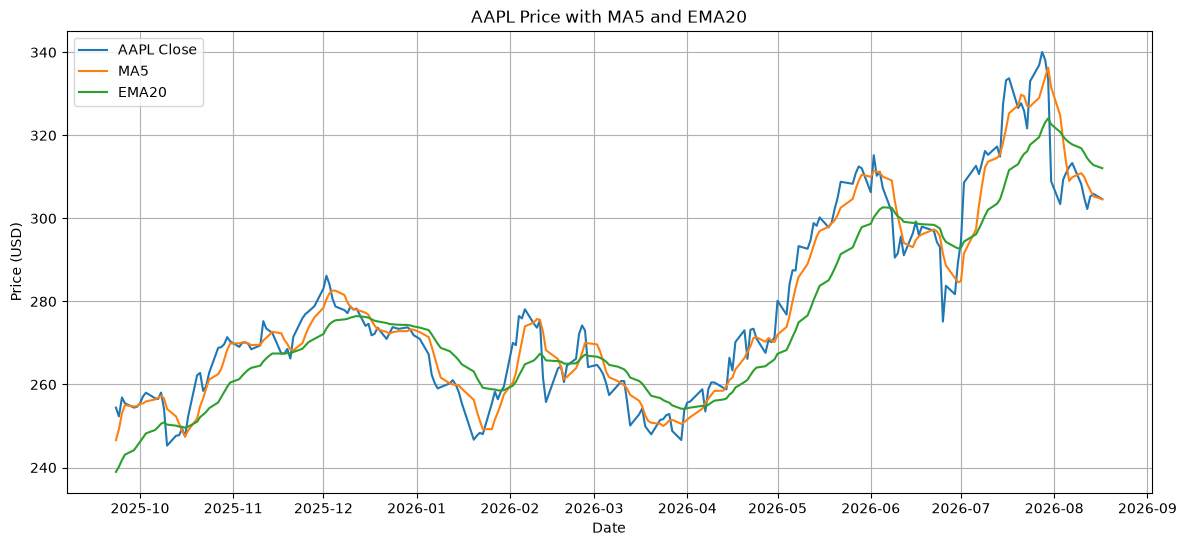

In [139]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, features["Close"], label="AAPL Close")
plt.plot(features.index, features["MA5"], label="MA5")
plt.plot(features.index, features["EMA20"], label="EMA20")

plt.title("AAPL Price with MA5 and EMA20")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

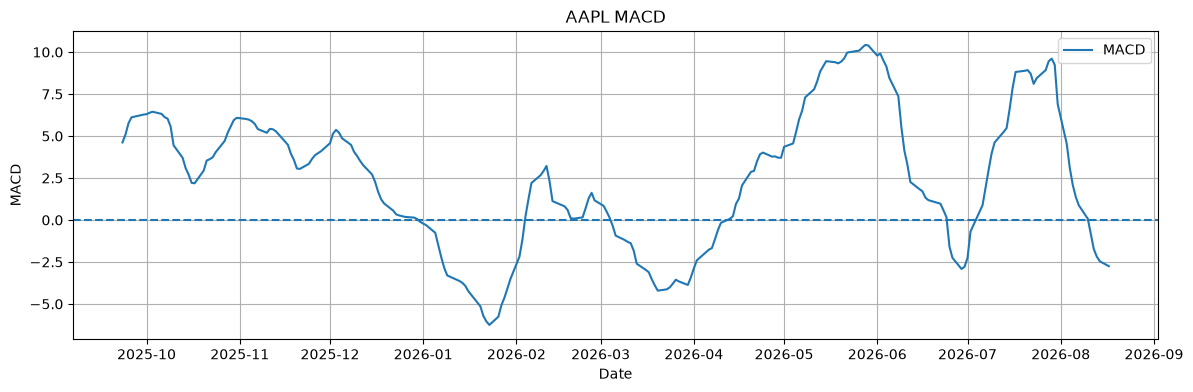

In [140]:
plt.figure(figsize=(14, 4))

plt.plot(
    features.index,
    features["MACD"],
    label="MACD"
)

plt.axhline(0, linestyle="--")

plt.title("AAPL MACD")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.grid(True)
plt.show()

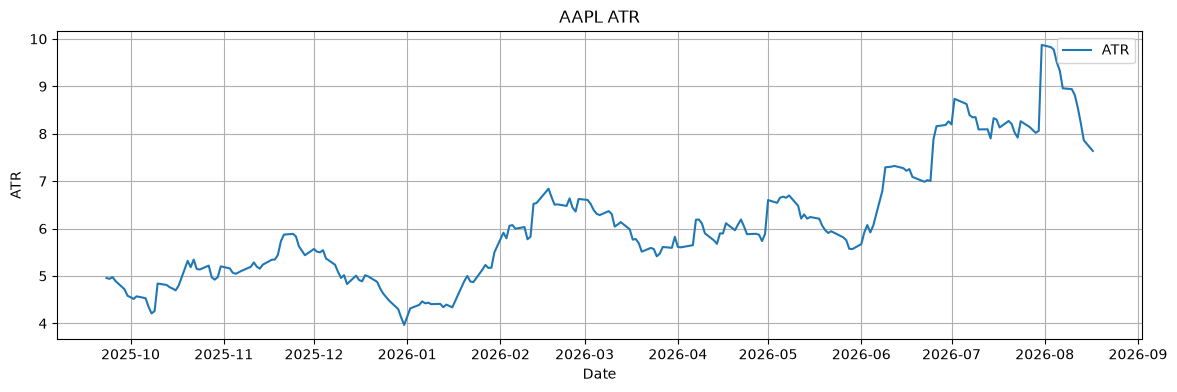

In [141]:
plt.figure(figsize=(14, 4))

plt.plot(
    features.index,
    features["ATR"],
    label="ATR"
)

plt.title("AAPL ATR")
plt.xlabel("Date")
plt.ylabel("ATR")
plt.legend()
plt.grid(True)
plt.show()

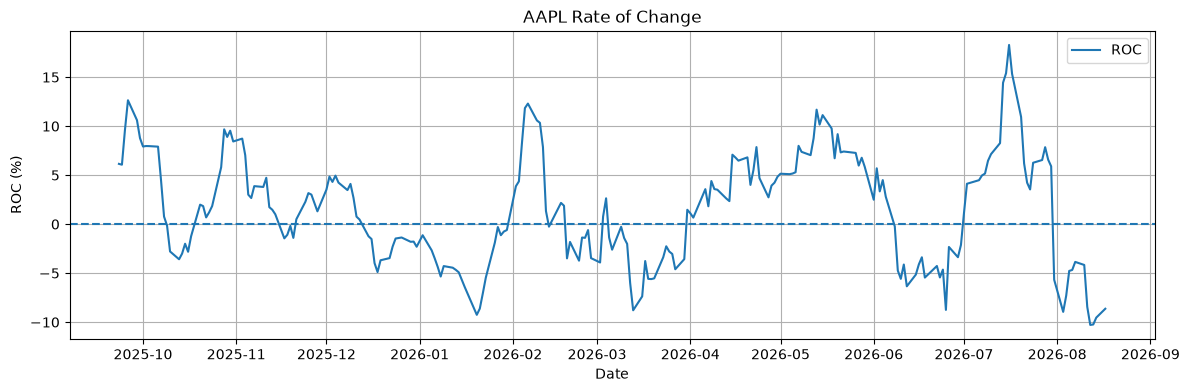

In [142]:
plt.figure(figsize=(14, 4))

plt.plot(
    features.index,
    features["ROC"],
    label="ROC"
)

plt.axhline(0, linestyle="--")

plt.title("AAPL Rate of Change")
plt.xlabel("Date")
plt.ylabel("ROC (%)")
plt.legend()
plt.grid(True)
plt.show()

In [143]:
processed_path = "../data/processed/AAPL_features.csv"

features.to_csv(processed_path)

print(f"Saved processed features to: {processed_path}")

Saved processed features to: ../data/processed/AAPL_features.csv


In [144]:
import os

print("File exists:", os.path.exists(processed_path))
print("File size:", os.path.getsize(processed_path), "bytes")

File exists: True
File size: 41071 bytes


In [145]:
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print("Instrument: AAPL")
print(f"Rows: {len(features)}")
print(f"Start: {features.index.min().date()}")
print(f"End: {features.index.max().date()}")

print("\nModel features:")
for feature in feature_columns:
    print(f"  - {feature}")

print("\nMissing feature values:")
print(features[feature_columns].isna().sum().sum())

FEATURE ENGINEERING SUMMARY
Instrument: AAPL
Rows: 226
Start: 2025-09-23
End: 2026-08-17

Model features:
  - Open
  - High
  - Low
  - Close
  - MA5
  - EMA20
  - MACD
  - ATR
  - ROC

Missing feature values:
0
